In [1]:
from collections import defaultdict

import gymnasium as gym
import numpy as np
from tqdm import tqdm

import src.utils as u
from src.CartAgent import CartAgent as QCartAgent
from src.CartAgent import prepare_input
from src.plots import draw_actions, draw_bin, draw_rolling_stats, draw_visit_count


In [2]:
learning_rate = 0.1
n_episodes = 200_000
start_epsilon = 1.0
epsilon_decay = start_epsilon / n_episodes 
final_epsilon = 0.2
discount_factor = .99

bin_count = 33
scale = (2, 1)

In [3]:
env = gym.make("CartPole-v1", render_mode=None)
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)
visit_counts = defaultdict(int)

In [4]:
bins_for_use = u.create_bins_for_use(env, bin_count, scale)

In [5]:
# draw_bin(bins_for_use[1])
# draw_bin(bins_for_use[3])

In [6]:
agent = QCartAgent(
    env=env,
    learning_rate=learning_rate,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
    bins=bins_for_use,
    decay_fn=u.exponential_decay(start_epsilon, final_epsilon, 1-epsilon_decay),
    discount_factor=discount_factor
)

In [7]:
for episode in tqdm(range(n_episodes)):
    obs, info = env.reset()
    done = False
    
    while not done:
        action = agent.get_action(obs)
        next_obs, reward, terminated, truncated, info = env.step(action)
        agent.update(obs, action, reward, terminated, next_obs)
        visit_counts[prepare_input(obs, bins_for_use)] += 1
        done = terminated or truncated
        obs = next_obs

    agent.decay()

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200000/200000 [08:14<00:00, 404.61it/s]


Q len: 26524


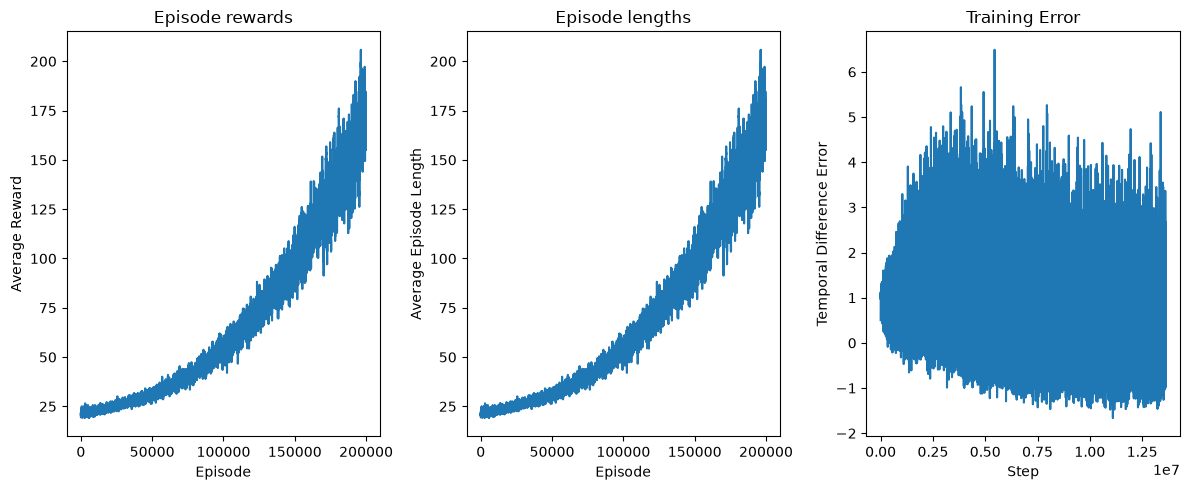

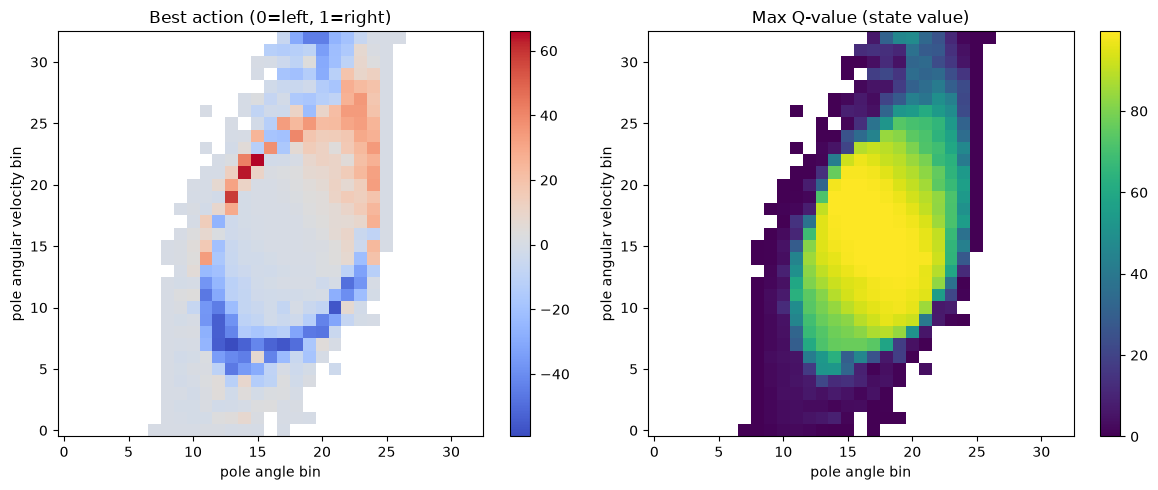

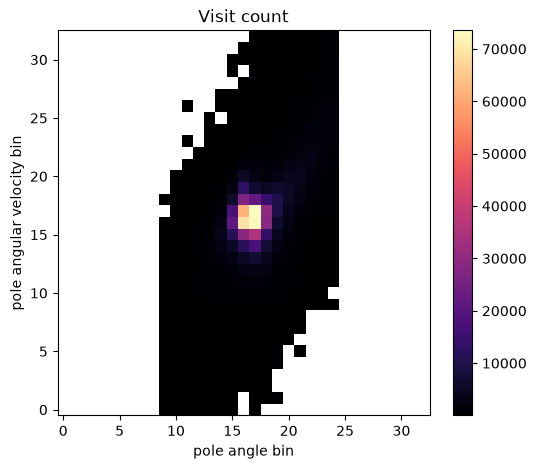

In [8]:
print("Q len:", len(agent.q_values))
draw_rolling_stats(env, agent)
draw_actions(agent, bin_count)
draw_visit_count(visit_counts, bin_count)

In [9]:
import pickle

with open(f"./data/q_table_{learning_rate}_{n_episodes}_{bin_count}_{scale[0]}_{scale[1]}_{discount_factor}_exp.pkl", "wb") as f:
    pickle.dump(dict(agent.q_values), f)

### Test case

Q test: 26604


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:05<00:00, 184.54it/s]

avg:  463.44


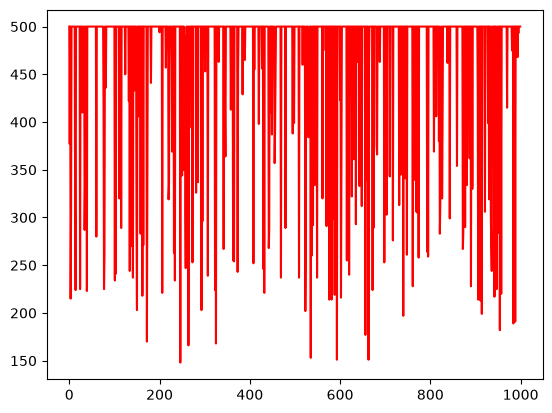

In [11]:
Q_test = agent.q_values
print("Q test:", len(Q_test))
test_env = gym.make("CartPole-v1", render_mode=None)

test_agent = QCartAgent(
    env=test_env,
    learning_rate=0,
    initial_epsilon=0,
    epsilon_decay=0,
    final_epsilon=0,
    bins=bins_for_use,
    decay_fn=lambda: 0,
)

test_agent.q_values = Q_test

test_reward = []

for n in tqdm(range(1000)):
    state, _ = test_env.reset()
    done = False
    total_reward = 0

    while not done:
        action = test_agent.get_action(state)
        next_state, reward, terminated, truncated, _ = test_env.step(action)
        done = terminated or truncated
        state = next_state
        total_reward += reward

    test_reward.append(total_reward)


print("avg: ", np.average(test_reward))
draw_bin(test_reward)